# 05 Q5 Feature Intervention

LaTeX position:

- `fig:behavior-regime-panels`

This slot is now used for counterfactual cue interventions and regime-sensitive evidence that routing is doing useful work.

What this figure should prove:

- Panel (a): semantically targeted interventions hurt quality in different ways.
- Panel (b): RouteRec gains are larger in behavioral regimes where routing becomes more selective, and that pattern is visible both slice by slice and in summary.

This keeps the focus on why MoE-style routing helps rather than on another family-level diagnostic heatmap.

In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import (
    dual_metric_grouped_plot,
    scatter_panel,
    setup_style,
)

setup_style()


def pivot_metric_frame(df, id_cols, metric_map):
    wide = df.pivot_table(index=id_cols, columns=['metric', 'cutoff'], values='value', aggfunc='first').reset_index()
    flattened = []
    for col in wide.columns:
        if isinstance(col, tuple):
            left, right = col
            if right == '':
                flattened.append(left)
            elif left == '':
                flattened.append(str(right))
            else:
                flattened.append(f"{left}_{right}")
        else:
            flattened.append(col)
    wide.columns = flattened
    rename_map = {}
    for new_name, (metric, cutoff) in metric_map.items():
        rename_map[f"{metric}_{cutoff}"] = new_name
    wide = wide.rename(columns=rename_map)
    for new_name in metric_map:
        if new_name not in wide.columns:
            wide[new_name] = np.nan
    return wide


def show_status_notes(df, placeholder_note=None, ready_note=None):
    if 'status' not in df.columns:
        return
    status_series = df['status'].dropna().astype(str)
    if status_series.empty:
        return
    if status_series.str.contains('placeholder', case=False).any() and placeholder_note:
        display(Markdown(placeholder_note))
    elif ready_note:
        display(Markdown(ready_note))


intervention_quality_df = pd.read_csv(DATA_DIR / '05_feature_intervention_scores.csv')
slice_quality_df = pd.read_csv(DATA_DIR / '05_behavior_slice_quality.csv')
slice_gain_df = pd.read_csv(DATA_DIR / '05_behavior_slice_gain.csv')

### (a) Semantic intervention quality

**Template status**: this panel is placeholder until eval-time semantic intervention hooks are added to the selected RouteRec run.

Recommended semantic interventions: shuffle_all, repeat_flatten, switch_boost, tempo_compress, popularity_spike
Needed export columns: intervention, metric, cutoff, value, split, selection_rule, run_id


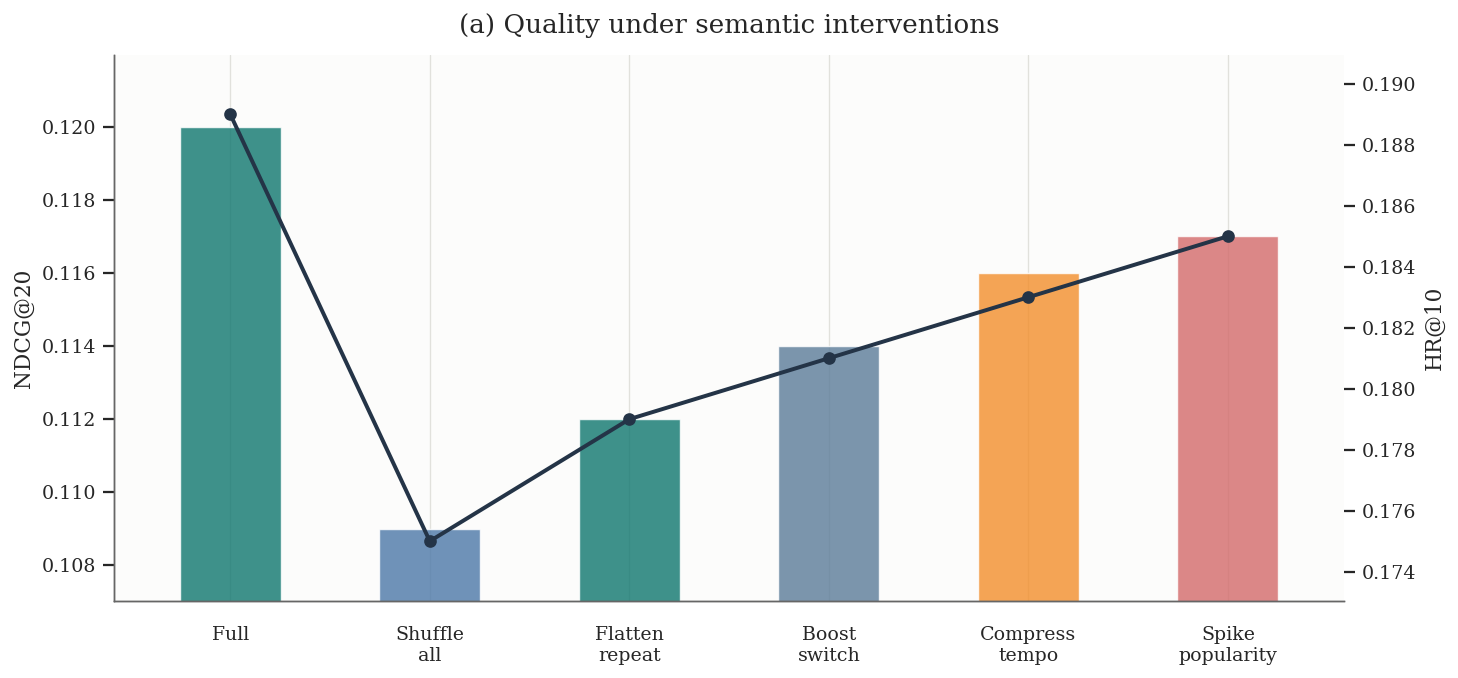

In [8]:
display(Markdown('### (a) Semantic intervention quality'))
show_status_notes(
    intervention_quality_df,
    placeholder_note='**Template status**: this panel is placeholder until eval-time semantic intervention hooks are added to the selected RouteRec run.',
)
print('Recommended semantic interventions: shuffle_all, repeat_flatten, switch_boost, tempo_compress, popularity_spike')
print('Needed export columns: intervention, metric, cutoff, value, split, selection_rule, run_id')

intervention_quality_plot_df = pivot_metric_frame(
    intervention_quality_df,
    id_cols=['intervention', 'variant_or_model'],
    metric_map={'ndcg20': ('NDCG', 20), 'hr10': ('HR', 10)},
).rename(columns={'variant_or_model': 'variant'})
intervention_label_map = {
    'full': 'Full',
    'shuffle_all': 'Shuffle\nall',
    'repeat_flatten': 'Flatten\nrepeat',
    'switch_boost': 'Boost\nswitch',
    'tempo_compress': 'Compress\ntempo',
    'popularity_spike': 'Spike\npopularity',
}

fig, ax = plt.subplots(figsize=(11.1, 5.1), constrained_layout=True)
dual_metric_grouped_plot(
    intervention_quality_plot_df,
    category_col='intervention',
    variant_col='variant',
    bar_col='ndcg20',
    line_col='hr10',
    ax=ax,
    title='(a) Quality under semantic interventions',
    bar_label='NDCG@20',
    line_label='HR@10',
    category_order=['full', 'shuffle_all', 'repeat_flatten', 'switch_boost', 'tempo_compress', 'popularity_spike'],
    category_labels=intervention_label_map,
    variant_order=['RouteRec'],
    rotate=0,
)
ax.tick_params(axis='x', pad=8)
plt.show()

### (b) Where routing helps most

**Template status**: this panel is placeholder until behavior-slice gain summaries are exported from held-out diagnostics.

This panel combines a slice-wise outcome view with a gain-vs-selectivity summary so the evidence does not feel too thin.
Needed logging: slice_name, variant_or_model, metric, cutoff, value, route_concentration, relative_gain after held-out slice aggregation


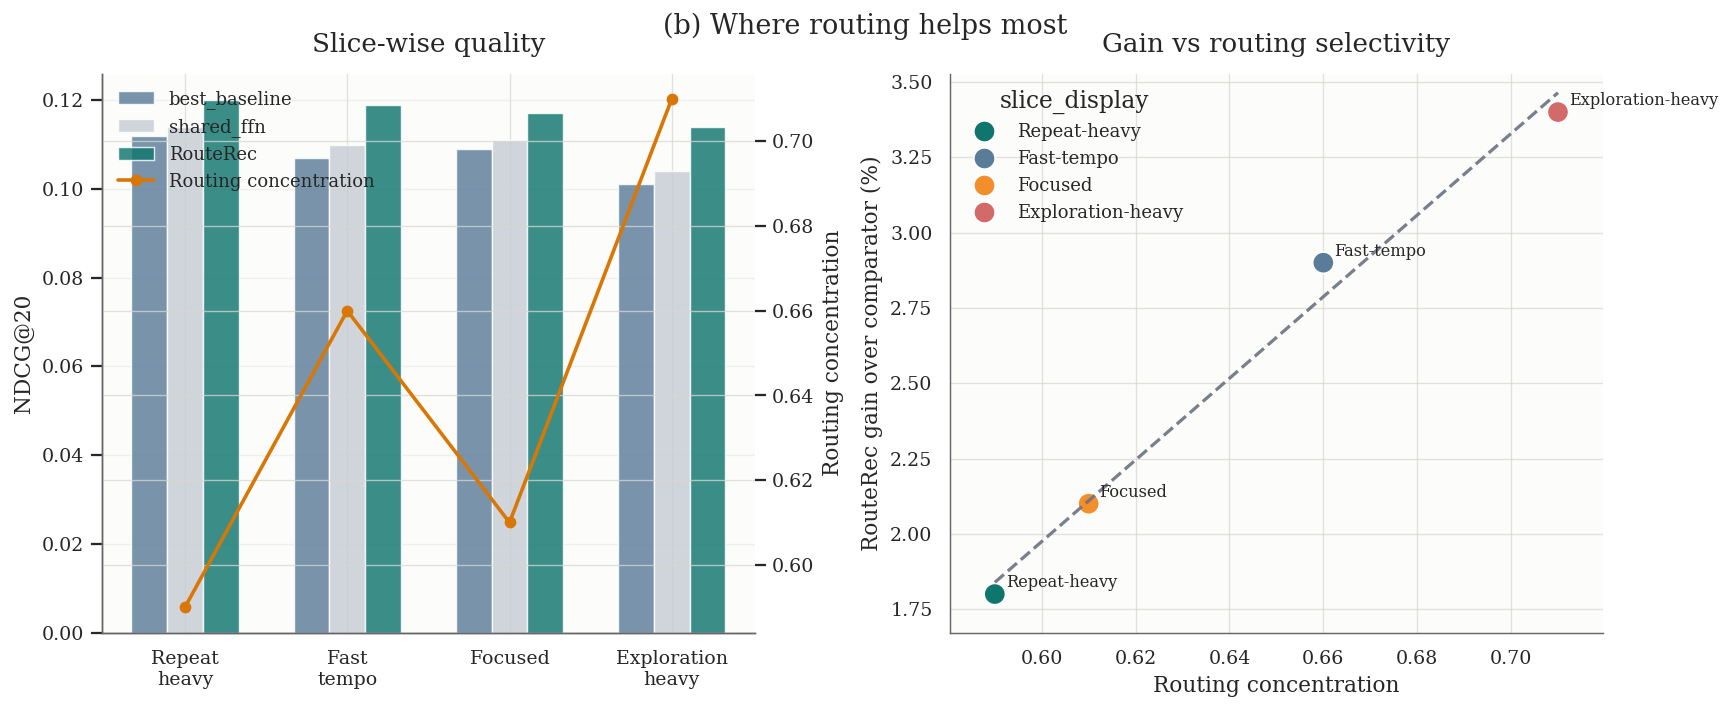

In [2]:
display(Markdown('### (b) Where routing helps most'))
show_status_notes(
    slice_gain_df,
    placeholder_note='**Template status**: this panel is placeholder until behavior-slice gain summaries are exported from held-out diagnostics.',
)
print('This panel combines a slice-wise outcome view with a gain-vs-selectivity summary so the evidence does not feel too thin.')
print('Needed logging: slice_name, variant_or_model, metric, cutoff, value, route_concentration, relative_gain after held-out slice aggregation')

slice_quality_plot_df = pivot_metric_frame(
    slice_quality_df,
    id_cols=['slice_name', 'variant_or_model'],
    metric_map={'ndcg20': ('NDCG', 20), 'hr10': ('HR', 10)},
).rename(columns={'variant_or_model': 'variant'})
slice_gain_plot_df = slice_gain_df.copy()
slice_gain_plot_df['relative_gain_pct'] = slice_gain_plot_df['relative_gain'] * 100.0
slice_gain_plot_df['slice_display'] = slice_gain_plot_df['slice_name'].map({
    'repeat-heavy': 'Repeat-heavy',
    'fast-tempo': 'Fast-tempo',
    'focused': 'Focused',
    'exploration-heavy': 'Exploration-heavy',
})
slice_order = ['repeat-heavy', 'fast-tempo', 'focused', 'exploration-heavy']
slice_label_map = {
    'repeat-heavy': 'Repeat\nheavy',
    'fast-tempo': 'Fast\ntempo',
    'focused': 'Focused',
    'exploration-heavy': 'Exploration\nheavy',
}
variant_order = ['best_baseline', 'shared_ffn', 'RouteRec']
variant_palette = {
    'best_baseline': '#5B7C99',
    'shared_ffn': '#C7CDD4',
    'RouteRec': '#0F766E',
}

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2), constrained_layout=True)

ax = axes[0]
x = np.arange(len(slice_order), dtype=float)
width = 0.22
for idx, variant in enumerate(variant_order):
    subset = slice_quality_plot_df[slice_quality_plot_df['variant'] == variant].set_index('slice_name')
    values = [subset.loc[slice_name, 'ndcg20'] for slice_name in slice_order]
    ax.bar(
        x + (idx - 1) * width,
        values,
        width=width,
        color=variant_palette[variant],
        alpha=0.82,
        edgecolor='white',
        linewidth=0.8,
        label=variant,
        zorder=2,
    )
ax.set_xticks(x)
ax.set_xticklabels([slice_label_map[key] for key in slice_order])
ax.set_ylabel('NDCG@20')
ax.set_title('Slice-wise quality')
ax.grid(axis='y', alpha=0.35)

twin = ax.twinx()
route_line = slice_gain_plot_df.set_index('slice_name').loc[slice_order, 'route_concentration']
twin.plot(
    x,
    route_line.values,
    color='#D97706',
    marker='o',
    linewidth=2.0,
    markersize=5.5,
    label='Routing concentration',
    zorder=3,
 )
twin.set_ylabel('Routing concentration')
handles, labels = ax.get_legend_handles_labels()
line_handles, line_labels = twin.get_legend_handles_labels()
ax.legend(handles + line_handles, labels + line_labels, loc='upper left', frameon=False)

scatter_panel(
    slice_gain_plot_df,
    x='route_concentration',
    y='relative_gain_pct',
    hue='slice_display',
    label_col='slice_display',
    ax=axes[1],
    title='Gain vs routing selectivity',
    ylabel='RouteRec gain over comparator (%)',
    xlabel='Routing concentration',
)
coef = np.polyfit(slice_gain_plot_df['route_concentration'], slice_gain_plot_df['relative_gain_pct'], deg=1)
x_grid = np.linspace(slice_gain_plot_df['route_concentration'].min(), slice_gain_plot_df['route_concentration'].max(), 100)
axes[1].plot(x_grid, coef[0] * x_grid + coef[1], linestyle='--', linewidth=1.8, color='#6B7280', alpha=0.9)
axes[1].axhline(0.0, linestyle=':', linewidth=1.1, color='#888888')

fig.suptitle('(b) Where routing helps most', y=1.02, fontsize=15)
plt.show()